In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import mutual_info_classif



In [ ]:
# mounting the drive to access dataset
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# setting the filepath to variable
filepath = "/content/drive/My Drive/Colab Notebooks/data/Iris.csv"
iris_data = pd.read_csv(filepath)
iris_data.describe() 

In [ ]:
# Seeing the correlation of the features
val = iris_data.corr(numeric_only=True)
val['PetalLengthCm'].sort_values(ascending=False)

In [ ]:
# Splitting the values to input features and output values
X_features = ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm']
y = iris_data["PetalLengthCm"]
X = iris_data[X_features]

In [ ]:
# Splitting the dataset into train set and test set
train_X, val_X, train_y, val_y = train_test_split(X,y,train_size=0.8,random_state=42)
train_X.columns

In [ ]:
# Visualizing the input features
from pandas.plotting import scatter_matrix

attributes = ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species']
scatter_matrix(iris_data,figsize=(12,8))
plt.show()

In [ ]:
class LinearRegresion():
    """
    LinearRegression using Gradient Descent from scratch

    This learns a linear relationship: y = X @ w + b
    by minimizing MSE using gradient descent.
    """
    def __init__(self, learning_rate = 0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss = []
        self.weights = None
        self.bias = None

    def fit(self, X,y):
        X = np.array(X)
        y = np.array(y)

        n_counts, n_features = X.shape

        self.bias = 0
        self.weights = np.random.randn(n_features) * 0.01


        for i in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            loss = y_pred - y
            self.loss.append(np.mean(loss**2))

            dw = (2/ n_counts) * np.dot(X.T, loss)
            db = 2 * np.mean(loss)

            self.weights = self.weights - self.learning_rate * dw
            self.bias -= self.learning_rate * db


    def predict(self, X):
        return np.dot(X,self.weights) + self.bias
    
    def r_sqr(self, X,y):
        y_pred = self.predict(X)
        y_true = np.array(y)

        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)

        return 1- (ss_res / ss_tot)
    


In [ ]:
# Normalizing the feature vector using z-normalization
train_X_scaled = (train_X - np.mean(train_X,axis=0)) / np.std(train_X,axis=0)
val_X_scaled = (val_X - np.mean(train_X, axis = 0)) / np.std(train_X, axis = 0)


In [ ]:
# Training the model and calculating the coefficient of determination
model = LinearRegresion(learning_rate=0.01,epochs=1000)
y_pred = model.fit(train_X_scaled,train_y)
print(model.r_sqr(val_X_scaled,val_y))



0.9567714941330263


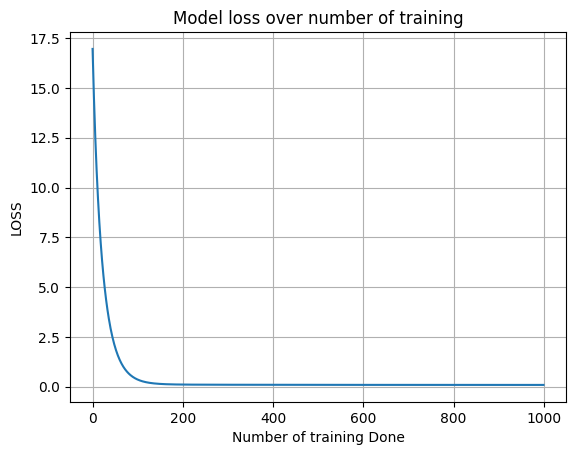

In [ ]:
# Seeing the loss curve of the model
plt.plot(model.loss)
plt.grid(True)
plt.xlabel("Number of training Done")
plt.ylabel("LOSS")
plt.title("Model loss over number of training")
plt.show()